In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Input: Image (28x28) -> Hidden Layer -> Mean and Variance ->  Reparameterization Trick -> Decoder  ->  Output: Image (28x28)
class VaritionalAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VaritionalAutoEncoder, self).__init__()
        # Encoder
        self.img_2hid = nn.Linear(input_dim, hidden_dim)
        self.hid_2mu = nn.Linear(hidden_dim, latent_dim)
        self.hid_2sigma = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.z_2hid = nn.Linear(latent_dim, hidden_dim)
        self.hid_2img = nn.Linear(hidden_dim, input_dim) # output dim = input dim

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    # Inference model of VAE : q(z|x)
    def encoder(self, x):
        hidden = self.relu(self.img_2hid(x))
        mu,sigma = self.hid_2mu(hidden), self.hid_2sigma(hidden)
        return mu, sigma
    
    # Generative model of VAE : p(x|z)
    def decoder(self, z):    
        hidden = self.relu(self.z_2hid(z))
        return torch.sigmoid(self.hid_2img(hidden))

    # VAE
    def forward(self, x):
        mu, sigma = self.encoder(x)
        epsilon = torch.randn_like(sigma)
        z = mu + sigma * epsilon
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, sigma

938it [00:08, 109.47it/s]
938it [00:07, 125.12it/s]
938it [00:07, 130.15it/s]
938it [00:08, 115.13it/s]
938it [00:07, 118.19it/s]
938it [00:07, 117.94it/s]
938it [00:07, 117.38it/s]
938it [00:07, 117.56it/s]
938it [00:08, 110.61it/s]
938it [00:07, 118.06it/s]
938it [00:08, 116.83it/s]
938it [00:08, 109.79it/s]
938it [00:08, 114.26it/s]
938it [00:07, 117.58it/s]
938it [00:08, 114.28it/s]
938it [00:08, 116.06it/s]
938it [00:08, 117.18it/s]
938it [00:08, 116.17it/s]
938it [00:08, 116.10it/s]
938it [00:08, 116.27it/s]
938it [00:08, 116.80it/s]
938it [00:08, 114.95it/s]
938it [00:08, 114.54it/s]
938it [00:08, 114.00it/s]
938it [00:08, 116.47it/s]
938it [00:08, 116.44it/s]
938it [00:08, 111.42it/s]
938it [00:08, 111.88it/s]
938it [00:08, 112.78it/s]
938it [00:08, 114.48it/s]


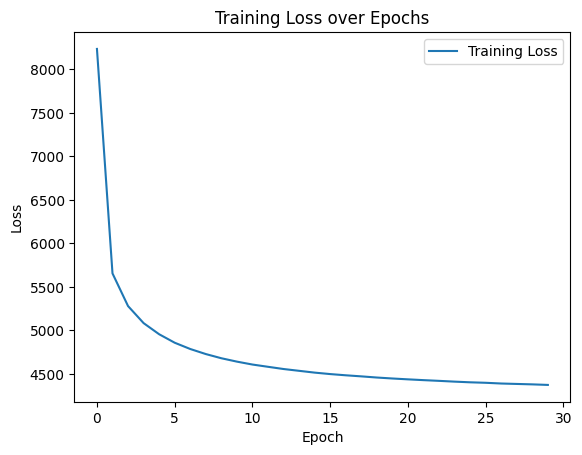

In [3]:

import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from VaritionalAutoEncoders import VaritionalAutoEncoder
from tqdm import tqdm
import numpy as np

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Congfiguration 
input_dim = 784
hidden_dim = 256
latent_dim = 20
nb_epochs = 30
bach_size = 64
lr_rate =  0.001

# Dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=bach_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=bach_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=bach_size, shuffle=False)

# Model
model = VaritionalAutoEncoder(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
model.train()
optimizer = optim.Adam(model.parameters(), lr=lr_rate)

# Training loss 
train_losses = []

# Training loop 
for epoch in range(nb_epochs):
    total_loss = 0
    loop = tqdm(enumerate(train_loader))
    
    for i, (x, _) in loop:
        # Forward pass
        x = x.to(device).view(x.size(0), input_dim)
        x_reconstructed, mu, sigma = model(x)

        # Compute loss
        res_loss = F.binary_cross_entropy(x_reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + sigma - mu.pow(2) - sigma.exp())
        loss = res_loss + kl_div
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # Tính loss trung bình cho epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Cập nhật tiến trình
    loop.set_description(f"Epoch [{epoch+1}/{nb_epochs}]")
    loop.set_postfix(loss=avg_loss)

# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

# Convert model to CPU
model = model.to('cpu')

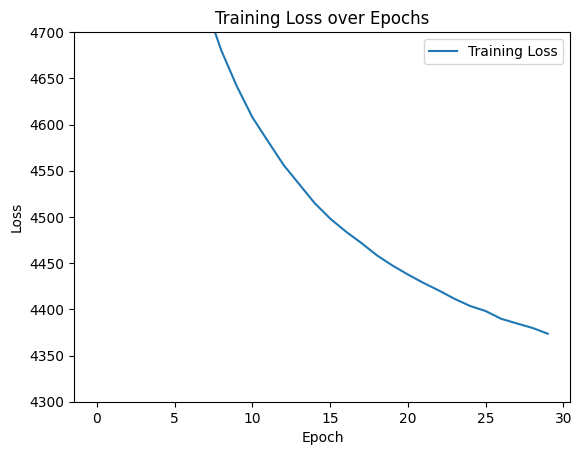

In [4]:
# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylim(4300,4700)
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

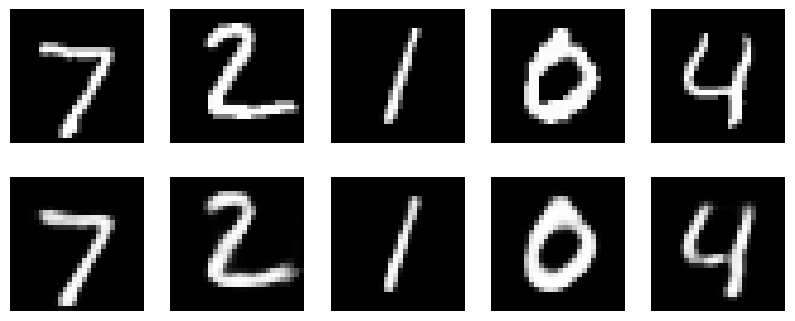

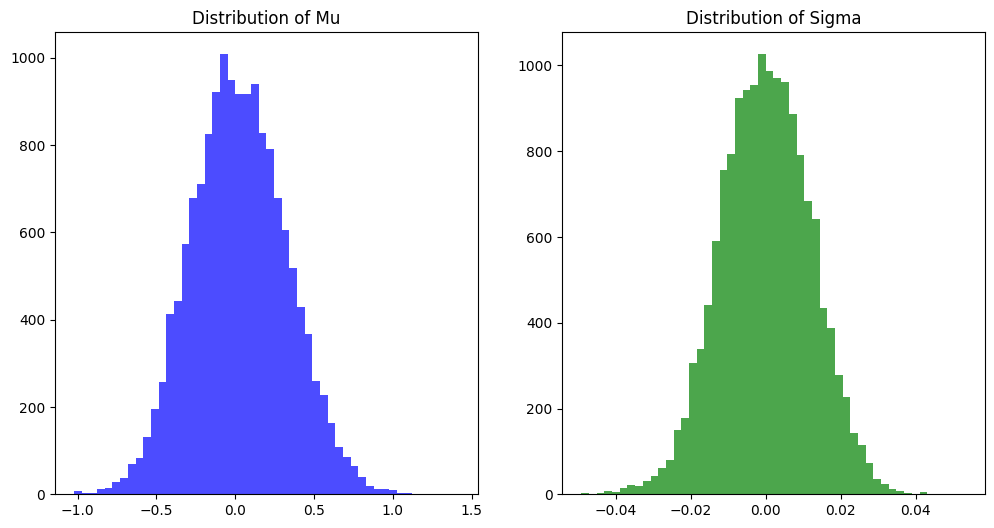

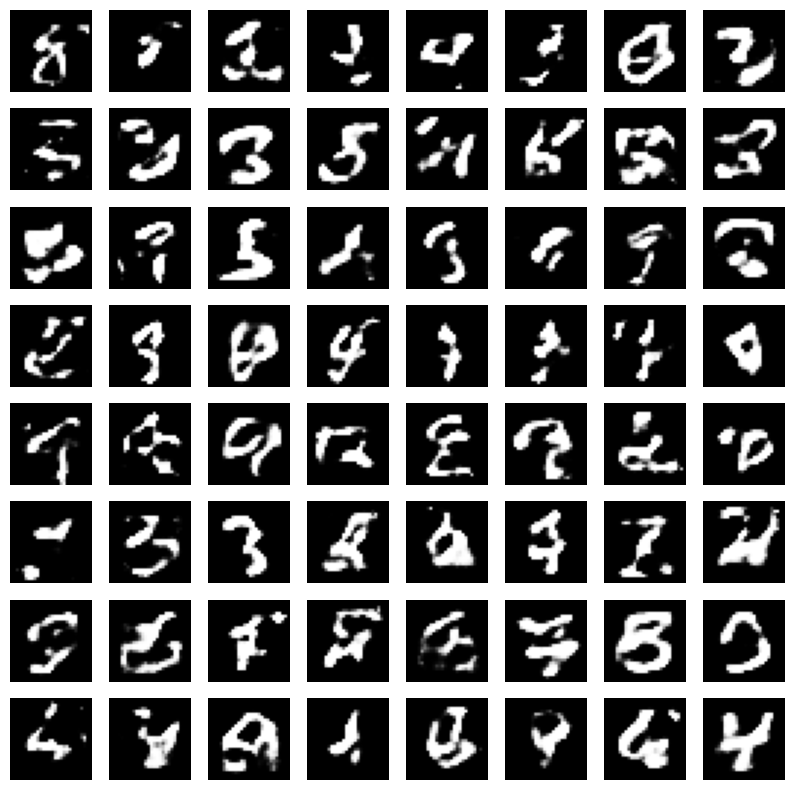

Reconstruction Loss (MSE) on Test Set: 6.4540


In [5]:
with torch.no_grad(): 
    for i, (x, _) in enumerate(test_loader):
        x = x.to(device).view(x.shape[0], input_dim)
        x_reconstructed, mu, sigma = model(x)
        
        # Display first 5 original and 5 reconstructed images
        if i == 0:
            fig, ax = plt.subplots(2, 5, figsize=(10, 4))
            for j in range(5):
                ax[0, j].imshow(x[j].cpu().numpy().reshape(28, 28), cmap='gray')
                ax[0, j].axis('off')
                ax[1, j].imshow(x_reconstructed[j].cpu().numpy().reshape(28, 28), cmap='gray')
                ax[1, j].axis('off')
            plt.show()
            break

# Check probability distribution of mu and sigma
mu_list = []
sigma_list = []

with torch.no_grad():
    for i, (x, _) in enumerate(test_loader):
        x = x.to(device).view(x.shape[0], input_dim)
        _, mu, sigma = model(x)
        
        mu_list.append(mu.cpu().numpy())
        sigma_list.append(sigma.cpu().numpy())

        if i > 10:  # Get data from first 10 batches
            break   # Stop after getting data from first 10 batches

# Convert to numpy arrays
mu_list = np.concatenate(mu_list, axis=0)
sigma_list = np.concatenate(sigma_list, axis=0)

# Display histograms of mu and sigma
plt.figure(figsize=(12, 6))

# Histogram of mu
plt.subplot(1, 2, 1)
plt.hist(mu_list.flatten(), bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Mu")

# Histogram of sigma
plt.subplot(1, 2, 2)
plt.hist(sigma_list.flatten(), bins=50, color='green', alpha=0.7)
plt.title("Distribution of Sigma")

plt.show()

# Generate new images from latent space
with torch.no_grad():
    # Make random vector form distribution normal
    random_z = torch.randn(64, latent_dim).to(device)
    
    # Generate new images
    x_generated = model.decoder(random_z)
    
    # Display generated images
    fig, ax = plt.subplots(8, 8, figsize=(10, 10))
    for i in range(64):
        ax[i // 8, i % 8].imshow(x_generated[i].cpu().numpy().reshape(28, 28), cmap='gray')
        ax[i // 8, i % 8].axis('off')
    plt.show()

def evaluate_model(model, dataloader, input_dim, device):
    """
    Evaluate a Variational Autoencoder model on a given dataset.

    Args:
        model: A Variational Autoencoder model.
        dataloader: A DataLoader object containing the dataset to evaluate on.
        input_dim: The dimensionality of the input data.
        device: The device to run the evaluation on.

    Returns:
        The average reconstruction loss (MSE) on the given dataset.
    """

    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device).view(x.size(0), input_dim) 
            x_reconstructed, _, _ = model(x)
            
            loss = F.mse_loss(x_reconstructed, x, reduction='sum')
            total_loss += loss.item()
    
    # Tính toán lỗi tái tạo trung bình trên tất cả các batch
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Reconstruction Loss (MSE) on Test Set: {avg_loss:.4f}")
    return avg_loss

# Evaluate model on test set
test_loss = evaluate_model(model, test_loader, input_dim, device)



In [6]:
import copy

def add_neurons(model, layer_name, nb_neurons):
    """
    Hàm để thêm neuron vào một lớp trong mô hình VAE.
    - model: Mô hình VAE ban đầu.
    - layer_name: Tên của lớp cần thêm neuron (img_2hid, hid_2mu, hid_2sigma, z_2hid, hoặc hid_2img).
    - nb_neurons: Số lượng neuron cần thêm.
    """
    new_model = copy.deepcopy(model)  # Tạo bản sao của mô hình để không thay đổi mô hình gốc
    layer = getattr(new_model, layer_name)  # Lấy lớp hiện tại theo tên
    
    # Tạo một lớp mới với số lượng neuron tăng thêm
    new_layer = nn.Linear(layer.in_features, layer.out_features + nb_neurons)
    
    # Sao chép trọng số của lớp cũ vào lớp mới
    with torch.no_grad():
        new_layer.weight[:layer.out_features, :] = layer.weight  # Sao chép trọng số cũ
        if layer.bias is not None:
            new_layer.bias[:layer.out_features] = layer.bias  # Sao chép bias
    
    # Thay thế lớp cũ trong mô hình bằng lớp mới
    setattr(new_model, layer_name, new_layer)
    return new_model

In [7]:
new_model = add_neurons(model, 'img_2hid', 0)  # Ví dụ: Thêm 10 neuron vào lớp 'img_2hid'
print(model)
print(new_model)


VaritionalAutoEncoder(
  (img_2hid): Linear(in_features=784, out_features=256, bias=True)
  (hid_2mu): Linear(in_features=256, out_features=20, bias=True)
  (hid_2sigma): Linear(in_features=256, out_features=20, bias=True)
  (z_2hid): Linear(in_features=20, out_features=256, bias=True)
  (hid_2img): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
VaritionalAutoEncoder(
  (img_2hid): Linear(in_features=784, out_features=256, bias=True)
  (hid_2mu): Linear(in_features=256, out_features=20, bias=True)
  (hid_2sigma): Linear(in_features=256, out_features=20, bias=True)
  (z_2hid): Linear(in_features=20, out_features=256, bias=True)
  (hid_2img): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


938it [00:08, 113.57it/s]
938it [00:08, 111.75it/s]
938it [00:08, 105.94it/s]
938it [00:08, 107.72it/s]
938it [00:08, 111.91it/s]
938it [00:08, 113.64it/s]
938it [00:07, 119.68it/s]
938it [00:08, 110.19it/s]
938it [00:09, 101.42it/s]
938it [00:08, 105.96it/s]
938it [00:08, 107.70it/s]
938it [00:08, 113.04it/s]
938it [00:08, 112.97it/s]
938it [00:08, 111.63it/s]
938it [00:09, 99.31it/s] 
938it [00:08, 106.13it/s]
938it [00:08, 111.70it/s]
938it [00:08, 107.42it/s]
938it [00:08, 115.03it/s]
938it [00:08, 111.93it/s]
938it [00:07, 118.39it/s]
938it [00:08, 106.08it/s]
938it [00:08, 114.42it/s]
938it [00:08, 116.00it/s]
938it [00:08, 113.94it/s]
938it [00:08, 110.22it/s]
938it [00:08, 112.43it/s]
938it [00:08, 116.17it/s]
938it [00:07, 125.85it/s]
938it [00:07, 126.43it/s]


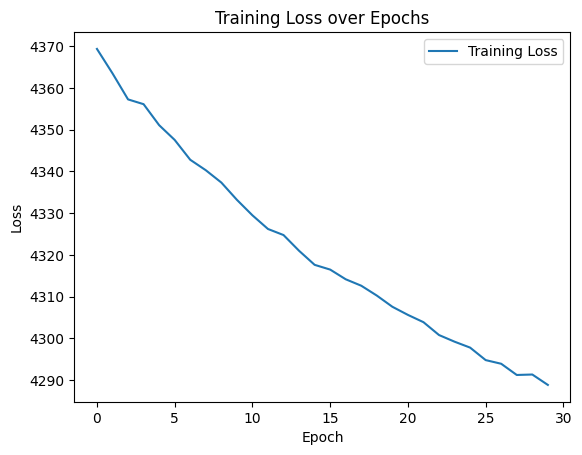

In [8]:
# Model
new_model.train()
optimizer = optim.Adam(new_model.parameters(), lr=lr_rate)

# Training loss 
train_losses = []

# Training loop 
for epoch in range(nb_epochs):
    total_loss = 0
    loop = tqdm(enumerate(train_loader))
    
    for i, (x, _) in loop:
        # Forward pass
        x = x.to(device).view(x.size(0), input_dim)
        x_reconstructed, mu, sigma = new_model(x)

        # Compute loss
        res_loss = F.binary_cross_entropy(x_reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + sigma - mu.pow(2) - sigma.exp())
        loss = res_loss + kl_div
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # Tính loss trung bình cho epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Cập nhật tiến trình
    loop.set_description(f"Epoch [{epoch+1}/{nb_epochs}]")
    loop.set_postfix(loss=avg_loss)

# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

# Convert model to CPU
new_model = new_model.to('cpu')

In [9]:
# Another function to add neurons - change input_dim of next layer
def add_neurons_to_layer(model, layer_name, nb_neurons):
    new_model = copy.deepcopy(model)
    
    # Retrieve the old layer to copy weights
    layer = getattr(new_model, layer_name)
    
    # Create a new layer with the increased number of neurons
    new_layer = nn.Linear(layer.in_features, layer.out_features + nb_neurons)
    
    # Copy the weights from the old layer to the new layer
    with torch.no_grad():
        new_layer.weight[:layer.out_features, :] = layer.weight
        if layer.bias is not None:
            new_layer.bias[:layer.out_features] = layer.bias

    setattr(new_model, layer_name, new_layer)

    # Adjust dependent layers
    if layer_name == 'img_2hid':
        # Retrieve the old layers for mu and sigma
        old_mu_layer = new_model.hid_2mu
        old_sigma_layer = new_model.hid_2sigma
        
        # Create new layers for mu and sigma with increased input size
        new_mu_layer = nn.Linear(layer.out_features + nb_neurons, old_mu_layer.out_features)
        new_sigma_layer = nn.Linear(layer.out_features + nb_neurons, old_sigma_layer.out_features)
        
        # Copy weights from the old mu and sigma layers to the new layers
        with torch.no_grad():
            new_mu_layer.weight[:, :old_mu_layer.in_features] = old_mu_layer.weight
            new_sigma_layer.weight[:, :old_sigma_layer.in_features] = old_sigma_layer.weight
            if old_mu_layer.bias is not None:
                new_mu_layer.bias = old_mu_layer.bias
            if old_sigma_layer.bias is not None:
                new_sigma_layer.bias = old_sigma_layer.bias
        
        # Assign the new layers to the model
        new_model.hid_2mu = new_mu_layer
        new_model.hid_2sigma = new_sigma_layer

    return new_model


In [10]:
new_model_30 = add_neurons_to_layer(model, 'img_2hid',nb_neurons = 50)  # Ví dụ: Thêm 10 neuron vào lớp 'img_2hid'
print(model)
print(new_model_30)

VaritionalAutoEncoder(
  (img_2hid): Linear(in_features=784, out_features=256, bias=True)
  (hid_2mu): Linear(in_features=256, out_features=20, bias=True)
  (hid_2sigma): Linear(in_features=256, out_features=20, bias=True)
  (z_2hid): Linear(in_features=20, out_features=256, bias=True)
  (hid_2img): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
VaritionalAutoEncoder(
  (img_2hid): Linear(in_features=784, out_features=306, bias=True)
  (hid_2mu): Linear(in_features=306, out_features=20, bias=True)
  (hid_2sigma): Linear(in_features=306, out_features=20, bias=True)
  (z_2hid): Linear(in_features=20, out_features=256, bias=True)
  (hid_2img): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


938it [00:09, 98.04it/s] 
938it [00:09, 97.66it/s] 
938it [00:09, 103.97it/s]
938it [00:09, 99.68it/s] 
938it [00:09, 103.79it/s]
938it [00:09, 102.46it/s]
938it [00:08, 107.77it/s]
938it [00:08, 104.94it/s]
938it [00:09, 97.37it/s] 
938it [00:09, 100.86it/s]
938it [00:09, 97.32it/s] 
938it [00:09, 93.84it/s] 
938it [00:10, 93.76it/s] 
938it [00:09, 99.38it/s] 
938it [00:08, 105.93it/s]
938it [00:08, 105.39it/s]
938it [00:08, 105.31it/s]
938it [00:09, 103.68it/s]
938it [00:10, 86.45it/s] 
938it [00:17, 54.50it/s]
938it [00:20, 45.67it/s]
938it [00:12, 73.64it/s]
938it [00:11, 81.83it/s]
938it [00:11, 82.52it/s]
938it [00:12, 77.88it/s]
938it [00:11, 79.03it/s]
938it [00:11, 84.07it/s]
938it [00:13, 69.79it/s]
938it [00:15, 58.73it/s]
938it [00:13, 71.45it/s]


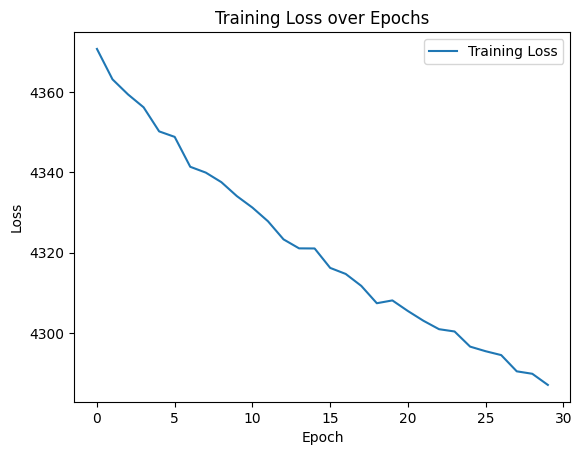

In [11]:
# Model
new_model_30.train()
optimizer = optim.Adam(new_model_30.parameters(), lr=lr_rate)

# Training loss 
train_losses = []

# Training loop 
for epoch in range(nb_epochs):
    total_loss = 0
    loop = tqdm(enumerate(train_loader))
    
    for i, (x, _) in loop:
        # Forward pass
        x = x.to(device).view(x.size(0), input_dim)
        x_reconstructed, mu, sigma = new_model_30(x)

        # Compute loss
        res_loss = F.binary_cross_entropy(x_reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + sigma - mu.pow(2) - sigma.exp())
        loss = res_loss + kl_div
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # Tính loss trung bình cho epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Cập nhật tiến trình
    loop.set_description(f"Epoch [{epoch+1}/{nb_epochs}]")
    loop.set_postfix(loss=avg_loss)

# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

# Convert model to CPU
new_model = new_model.to('cpu')

In [12]:
from torchviz import make_dot

# Khởi tạo mô hình và dữ liệu
vae_model = VaritionalAutoEncoder(input_dim=28*28, hidden_dim=256, latent_dim=64)
dummy_input = torch.randn(1, 28*28)  # Sử dụng một input giả để vẽ mô hình

# Lấy đồ thị trực quan
output, mu, sigma = model(dummy_input)
dot = make_dot(output, params=dict(model.named_parameters()))

# Lưu đồ thị vào file PNG
dot.render("vae_model", format="png")

# Nếu muốn hiển thị trực tiếp trong Jupyter Notebook
dot.view()


'vae_model.pdf'